In [1]:
import pandas as pd

labels_path = "data/train_labels.csv"
sequences_path = "data/train_sequences.csv"

labels = pd.read_csv(labels_path).dropna()
sequences = pd.read_csv(sequences_path)
sequences.head()

,target_id,sequence,temporal_cutoff,description,all_sequences
0,1SCL_A,GGGUGCUCAGUACGAGAGGAACCGCACCC,1995-01-26,"THE SARCIN-RICIN LOOP, A MODULAR RNA",>1SCL_1|Chain A|RNA SARCIN-RICIN LOOP|Rattus n...
1,1RNK_A,GGCGCAGUGGGCUAGCGCCACUCAAAAGGCCCAU,1995-02-27,THE STRUCTURE OF AN RNA PSEUDOKNOT THAT CAUSES...,>1RNK_1|Chain A|RNA PSEUDOKNOT|null\nGGCGCAGUG...
2,1RHT_A,GGGACUGACGAUCACGCAGUCUAU,1995-06-03,24-MER RNA HAIRPIN COAT PROTEIN BINDING SITE F...,>1RHT_1|Chain A|RNA (5'-R(P*GP*GP*GP*AP*CP*UP*...
3,1HLX_A,GGGAUAACUUCGGUUGUCCC,1995-09-15,P1 HELIX NUCLEIC ACIDS (DNA/RNA) RIBONUCLEIC ACID,>1HLX_1|Chain A|RNA (5'-R(*GP*GP*GP*AP*UP*AP*A...
4,1HMH_E,GGCGACCCUGAUGAGGCCGAAAGGCCGAAACCGU,1995-12-07,THREE-DIMENSIONAL STRUCTURE OF A HAMMERHEAD RI...,">1HMH_1|Chains A, C, E|HAMMERHEAD RIBOZYME-RNA..."


In [2]:
labels.head()

,ID,resname,resid,x_1,y_1,z_1
0,1SCL_A_1,G,1,13.760,-25.974001,0.102
1,1SCL_A_2,G,2,9.310,-29.638000,2.669
2,1SCL_A_3,G,3,5.529,-27.813000,5.878
3,1SCL_A_4,U,4,2.678,-24.900999,9.793
4,1SCL_A_5,G,5,1.827,-20.136000,11.793


Processing ID: 1SCL_A
Processing ID: 1RNK_A
Processing ID: 1RHT_A
Processing ID: 1HLX_A
Processing ID: 1HMH_E
Processing ID: 1RNG_A
Processing ID: 1MME_D
Processing ID: 1KAJ_A
Processing ID: 1SLO_A
Processing ID: 1BIV_A
Processing ID: 1ANR_A
Processing ID: 1ZIG_A
Processing ID: 1ZIH_A
Processing ID: 1ETF_A
Processing ID: 1ZIF_A
Processing ID: 1KPD_A
Processing ID: 1IKD_A
Processing ID: 1ZDI_S
Processing ID: 1AFX_A
Processing ID: 1EBQ_A
Processing ID: 1EBR_A
Processing ID: 1ULL_A
Processing ID: 1KIS_B
Processing ID: 1KIS_A
Processing ID: 1ATO_A
Processing ID: 1TLR_A
Processing ID: 1VOP_A
Processing ID: 1AQO_A
Processing ID: 1ATV_A
Processing ID: 1ATW_A
Processing ID: 1UUU_A
Processing ID: 1AUD_B
Processing ID: 2U2A_A
Processing ID: 1A4T_A
Processing ID: 1A60_A
Processing ID: 1A51_A
Processing ID: 2A9L_A
Processing ID: 1A1T_B
Processing ID: 1A9N_Q
Processing ID: 3PHP_A
Processing ID: 2TPK_A
Processing ID: 7MSF_S
Processing ID: 5MSF_S
Processing ID: 1LDZ_A
Processing ID: 1ZDK_S
Processing

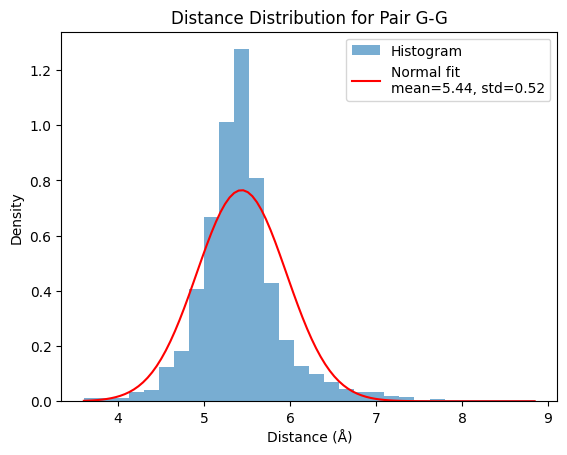

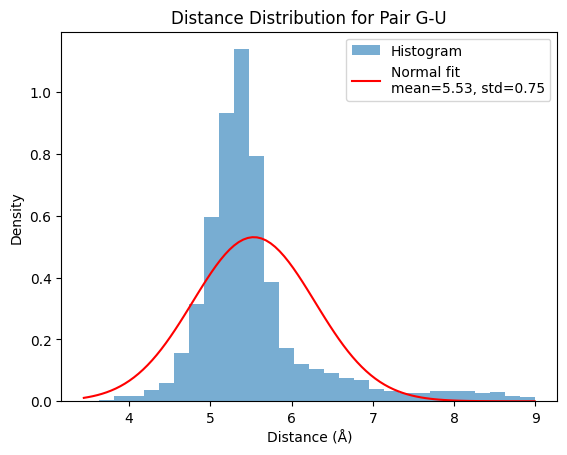

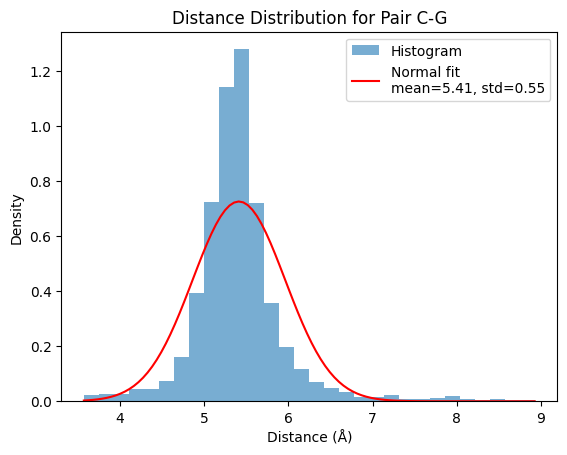

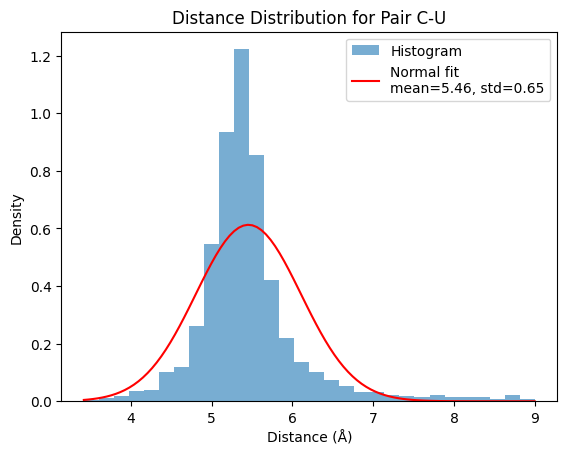

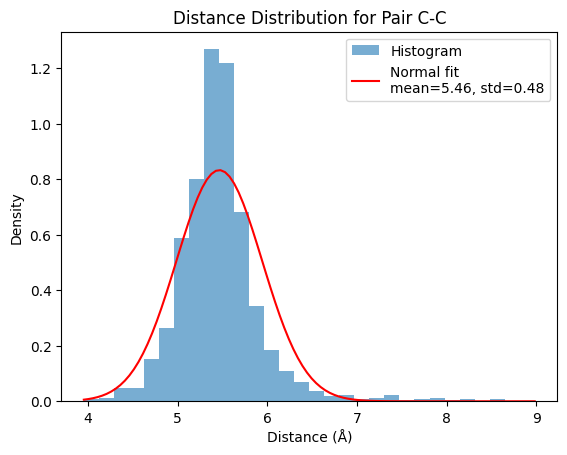

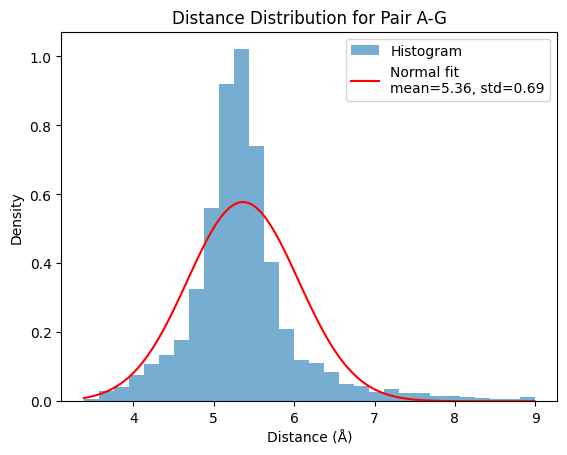

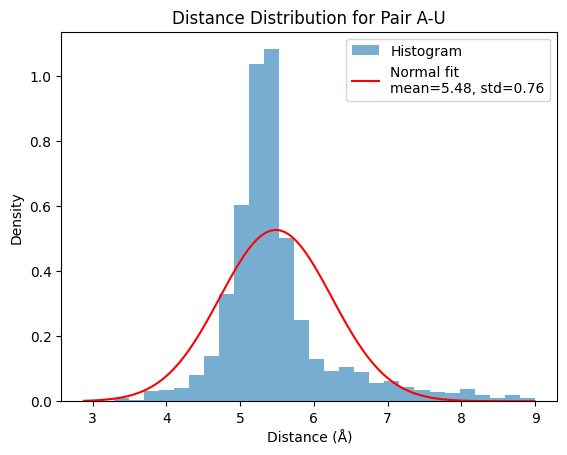

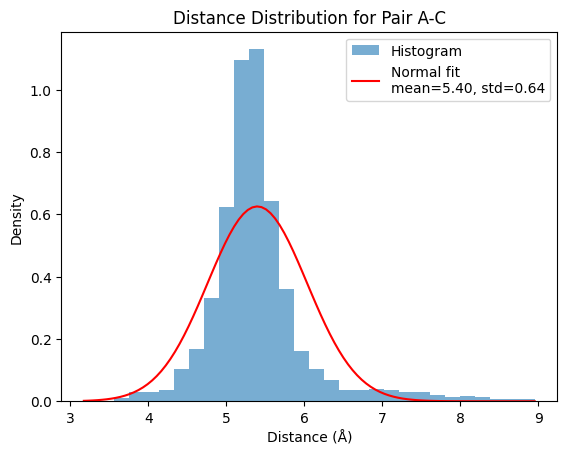

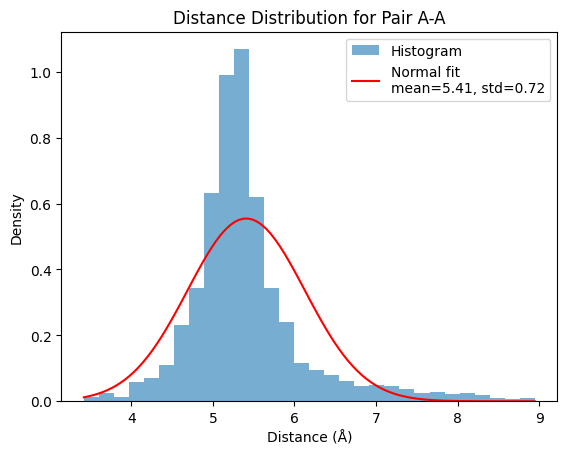

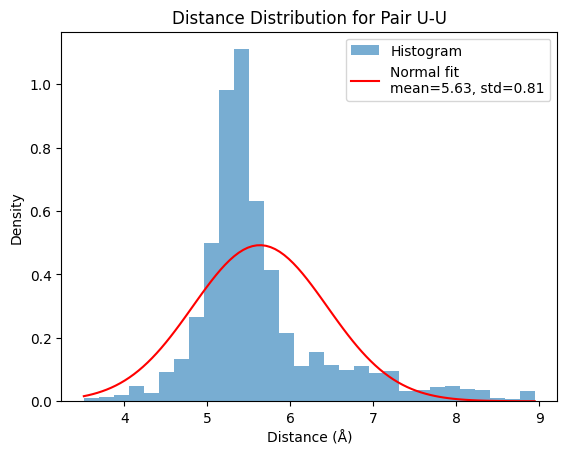

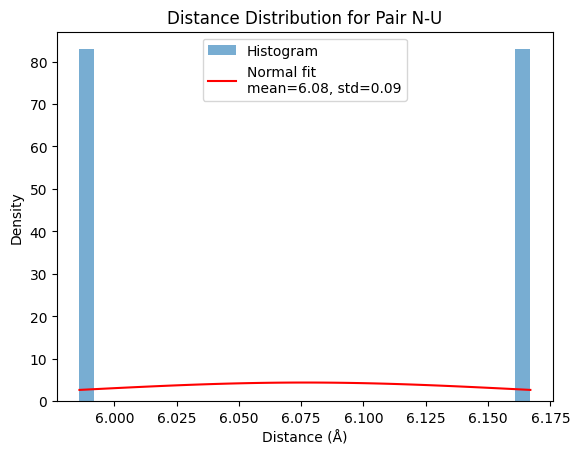

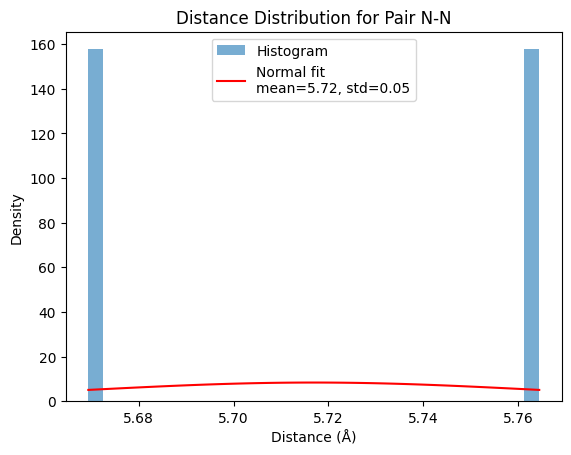

,count,min_distance,max_distance,avg_distance,base_pair_count,not_base_pair_count
G-G,3791,3.602628,8.846570,5.436879,3549,242
G-U,4823,3.442523,8.992719,5.534807,4519,304
C-G,5620,3.572307,8.925190,5.413246,5373,247
C-U,4649,3.421118,8.996630,5.455930,4284,365
C-C,2704,3.951935,8.980566,5.462678,2631,73
A-G,5780,3.384155,8.993115,5.363235,5104,676
A-U,3550,2.880371,8.993493,5.483644,3173,377
A-C,4408,3.171940,8.956301,5.397673,4090,318
A-A,2744,3.417596,8.945462,5.407839,2506,238
U-U,2259,3.511978,8.943457,5.633032,2119,140


In [ ]:
# ===== Studying Pairwise Distances Between Residues ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IGNORE_BASE_PAIRS = False

pair_stats = {}
pair_distances = {}  # to store all distances for each pair key

# Iterate over each target_id in your sequences DataFrame.
IDs = sequences['target_id'].values

for ID in IDs:
    print(f"Processing ID: {ID}")
    # Filter the labels DataFrame for the current ID and limit to 100 entries.
    filtered_df = labels[labels['ID'].str.contains(ID)].iloc[:100].reset_index(drop=True)

    # Extract coordinates from the filtered DataFrame.
    coords = filtered_df[['x_1', 'y_1', 'z_1']].values

    # Calculate the full pairwise Euclidean distance matrix.
    diff = coords[:, None, :] - coords[None, :, :]
    dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
    
    # Loop over each residue in the filtered set.
    for i in range(len(coords)):
        distances = dist_matrix[i].copy()
        distances[i] = np.inf  # ignore self-distance
        
        closest_idx = np.argmin(distances)
        closest_distance = distances[closest_idx]
        
        # Retrieve residue types from the filtered DataFrame (with matching indices).
        res_i_type = filtered_df.iloc[i]['resname']
        res_j_type = filtered_df.iloc[closest_idx]['resname']
        
        # Check if the closest residue is a direct neighbor.
        is_base_pair = abs(i - closest_idx) == 1
        if is_base_pair and IGNORE_BASE_PAIRS:
            continue
        
        # Replace non-standard residue types with 'N'
        if res_i_type not in ['A', 'C', 'G', 'U']:
            res_i_type = 'N'
        if res_j_type not in ['A', 'C', 'G', 'U']:
            res_j_type = 'N'
        
        # Sort the residue types alphabetically to form a consistent key.
        pair_key = tuple(sorted([res_i_type, res_j_type]))
        
        # Ignore distances greater than 9 Å.
        if closest_distance > 9:
            continue
        
        # Update or create the stats entry for this residue pair.
        if pair_key in pair_stats:
            pair_stats[pair_key]["count"] += 1
            pair_stats[pair_key]["total_distance"] += closest_distance
            pair_stats[pair_key]["min_distance"] = min(pair_stats[pair_key]["min_distance"], closest_distance)
            pair_stats[pair_key]["max_distance"] = max(pair_stats[pair_key]["max_distance"], closest_distance)
            pair_stats[pair_key]["avg_distance"] = pair_stats[pair_key]["total_distance"] / pair_stats[pair_key]["count"]
            if is_base_pair:
                pair_stats[pair_key]["base_pair_count"] += 1
            else:
                pair_stats[pair_key]["not_base_pair_count"] += 1
        else:
            pair_stats[pair_key] = {
                "count": 1,
                "total_distance": closest_distance,
                "min_distance": closest_distance,
                "max_distance": closest_distance,
                "avg_distance": closest_distance,
                "base_pair_count": 1 if is_base_pair else 0,
                "not_base_pair_count": 0 if is_base_pair else 1
            }
        
        # Also save this distance for the distribution plot.
        if pair_key in pair_distances:
            pair_distances[pair_key].append(closest_distance)
        else:
            pair_distances[pair_key] = [closest_distance]

# Convert pair_stats keys to a string format for DataFrame display.
pair_stats_str = {f"{k[0]}-{k[1]}": v for k, v in pair_stats.items()}
pair_stats_df = pd.DataFrame.from_dict(pair_stats_str, orient='index')
# Optionally, drop the total_distance column if it's not needed.
pair_stats_df = pair_stats_df.drop(columns=["total_distance"])

# Plot distributions for each pair with a fitted bell curve.
for pair_key, dists in pair_distances.items():
    plt.figure()
    # Plot histogram (normalized to form a density)
    plt.hist(dists, bins=30, density=True, alpha=0.6, label="Histogram")
    
    # Compute mean and standard deviation of the distribution.
    mean = np.mean(dists)
    std = np.std(dists)
    
    # Create points for plotting a fitted normal distribution (bell curve).
    x_values = np.linspace(min(dists), max(dists), 100)
    normal_pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(- ((x_values - mean) ** 2) / (2 * std**2))
    
    plt.plot(x_values, normal_pdf, 'r-', label=f"Normal fit\nmean={mean:.2f}, std={std:.2f}")
    plt.title(f"Distance Distribution for Pair {pair_key[0]}-{pair_key[1]}")
    plt.xlabel("Distance (Å)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

pair_stats_df
